In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_excel("LIGHTWEIGHT_CONCRETE.xlsx", header=[0,1,2])

In [4]:
df.head()

S. No                  Authors Input Variables           \
  Unnamed: 0_level_1       Unnamed: 1_level_1          Binder Pozzolan   
  Unnamed: 0_level_2       Unnamed: 1_level_2         (kg/m3)  (kg/m3)   
0                  1  Tikalsky., et al., 2004           420.0      0.0   
1                  2                      NaN           411.0      0.0   
2                  3                      NaN           149.0    302.0   
3                  4                      NaN           311.0      0.0   
4                  5                      NaN            57.0    268.0   

                                                                           \
  Fine aggregate   Water Foaming agent Measured Density Period of Testing   
         (kg/m3) (kg/m3)       (kg/m3)          (kg/m3)            (Days)   
0            0.0   168.0          39.4            629.0                28   
1            0.0   186.0          38.5            631.0                28   
2            0.0   190.0          35.8            678.0                28   
3            0.0   141.0          44.3            497.0                28   
4          885.0   163.0          20.0           1396.0                28   

      Output Variables  
  Compressive Strength  
                 (MPa)  
0                 1.77  
1                 2.07  
2                 1.09  
3                 0.71  
4                 0.25

In [5]:
df.columns = ["s.no", "authors", "binder", "pozzolan", "fine aggregate", "water", "foaming agent", "density", "age", "compressive strength"]

df.columns

Index(['s.no', 'authors', 'binder', 'pozzolan', 'fine aggregate', 'water',
       'foaming agent', 'density', 'age', 'compressive strength'],
      dtype='object')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

s.no                      0
authors                 984
binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [8]:
df = df.iloc[:, 2:]

df.isnull().sum()

binder                    0
pozzolan                406
fine aggregate            0
water                     0
foaming agent             0
density                   0
age                       0
compressive strength      0
dtype: int64

In [9]:
df.fillna(0, inplace=True)

df.isnull().sum()

binder                  0
pozzolan                0
fine aggregate          0
water                   0
foaming agent           0
density                 0
age                     0
compressive strength    0
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_dataset(df, dataset_name):
    print(f"--- Exploratory Data Analysis for {dataset_name} ---")
    
    plt.figure(figsize=(10, 8))
    
    target = 'compressive strength'
    if target in df.columns:
        features = [col for col in df.columns if col != target]
        fig, axes = plt.subplots(nrows=int(len(features)/3) + 1, ncols=3, figsize=(15, 12))
        axes = axes.flatten()
        
        for i, col in enumerate(features):
            sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{col} vs {target}')
            
        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])
            
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df, orient="h", palette="Set2")
    plt.title(f'Boxplots (Outlier Detection) - {dataset_name}')
    plt.tight_layout()
    plt.show()
    

    corr_matrix = df.corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title(f'Correlation Matrix - {dataset_name}')
    plt.show()
    
    
    num_cols = len(df.columns)
    df.hist(bins=30, figsize=(15, 12), layout=(int(num_cols/3) + 1, 3))
    plt.suptitle(f'Histograms (Distributions) - {dataset_name}', fontsize=16)
    plt.tight_layout()
    plt.show()


Lightweight original: 1006 rows
Lightweight after cleaning: 912 rows

--- Exploratory Data Analysis for Lightweight Concrete (light_df) ---


<Figure size 1000x800 with 0 Axes>

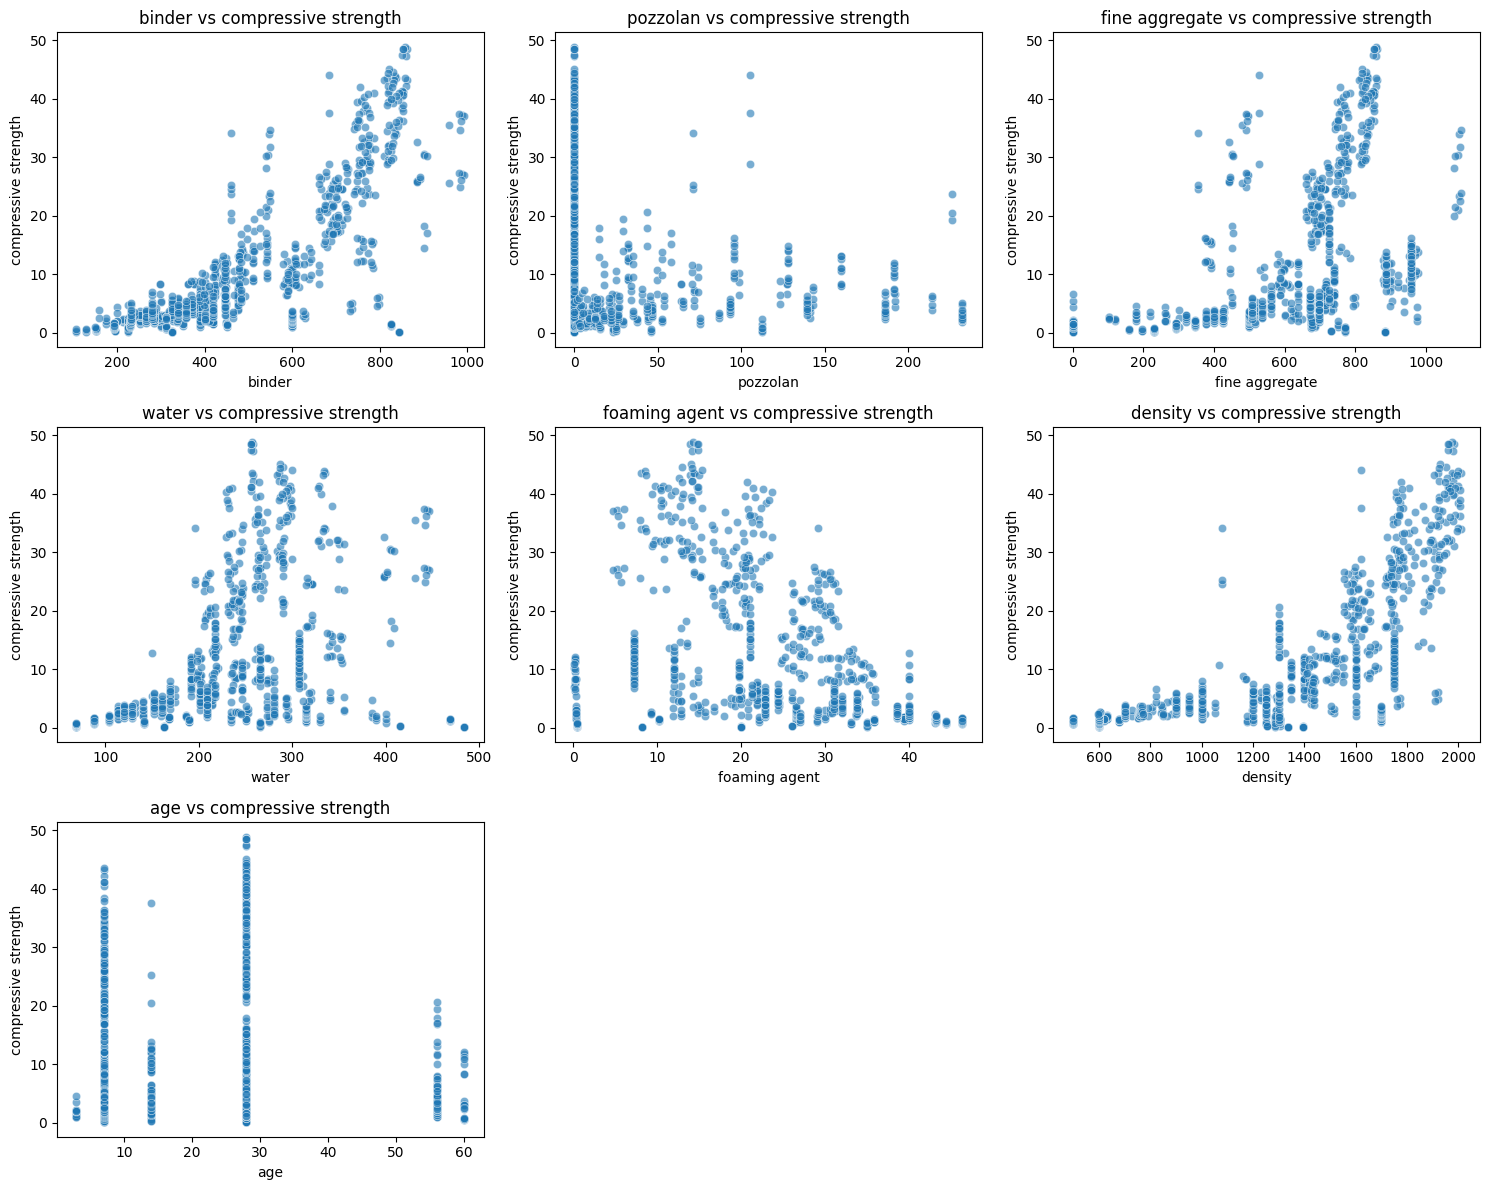

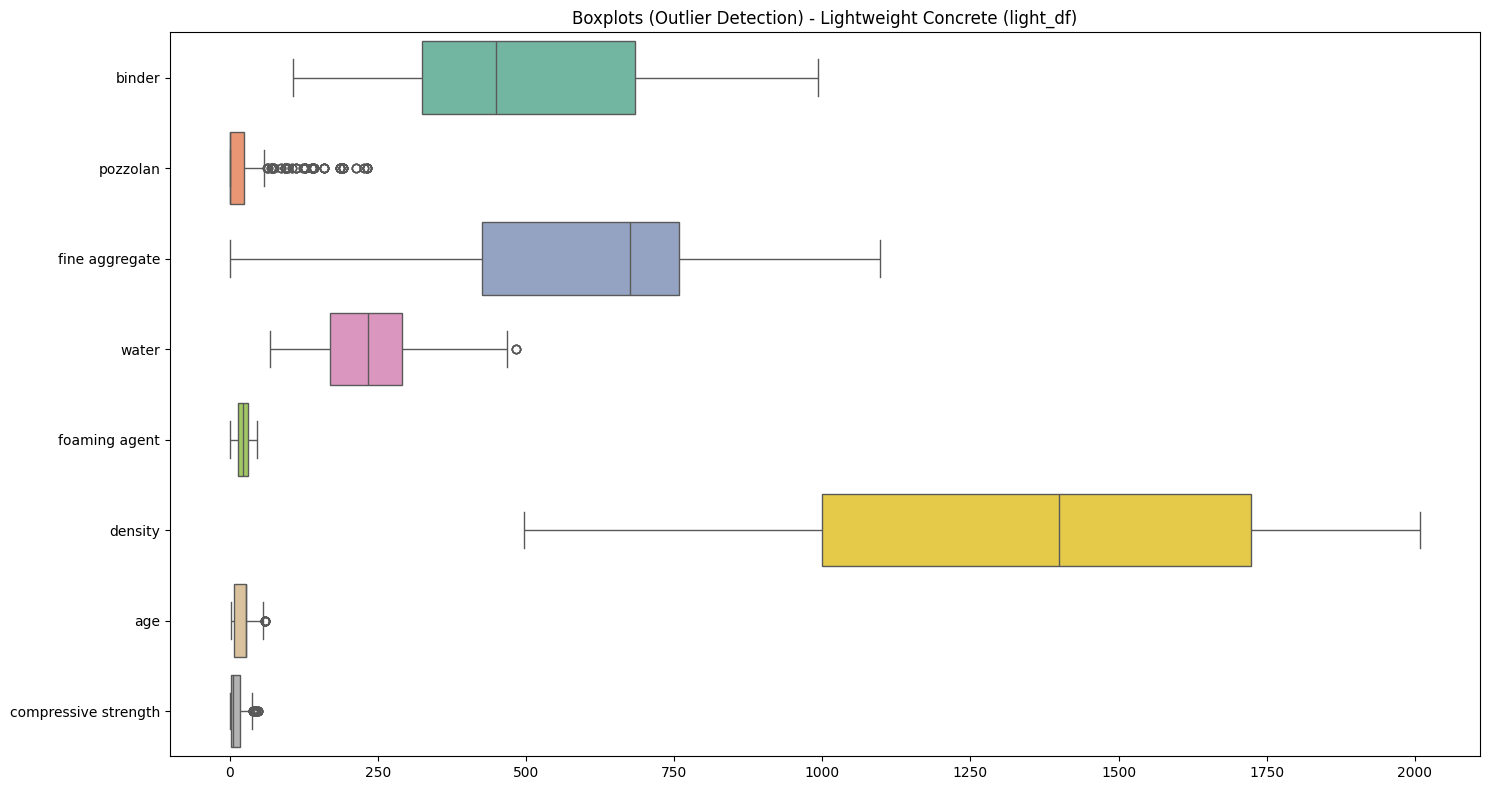

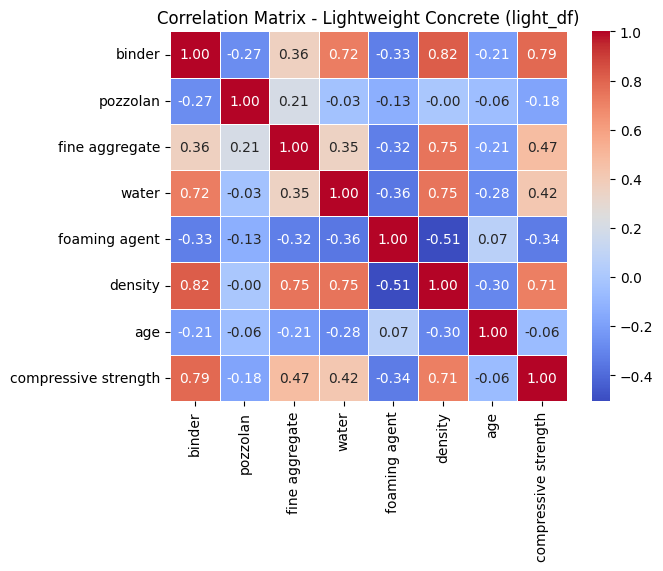

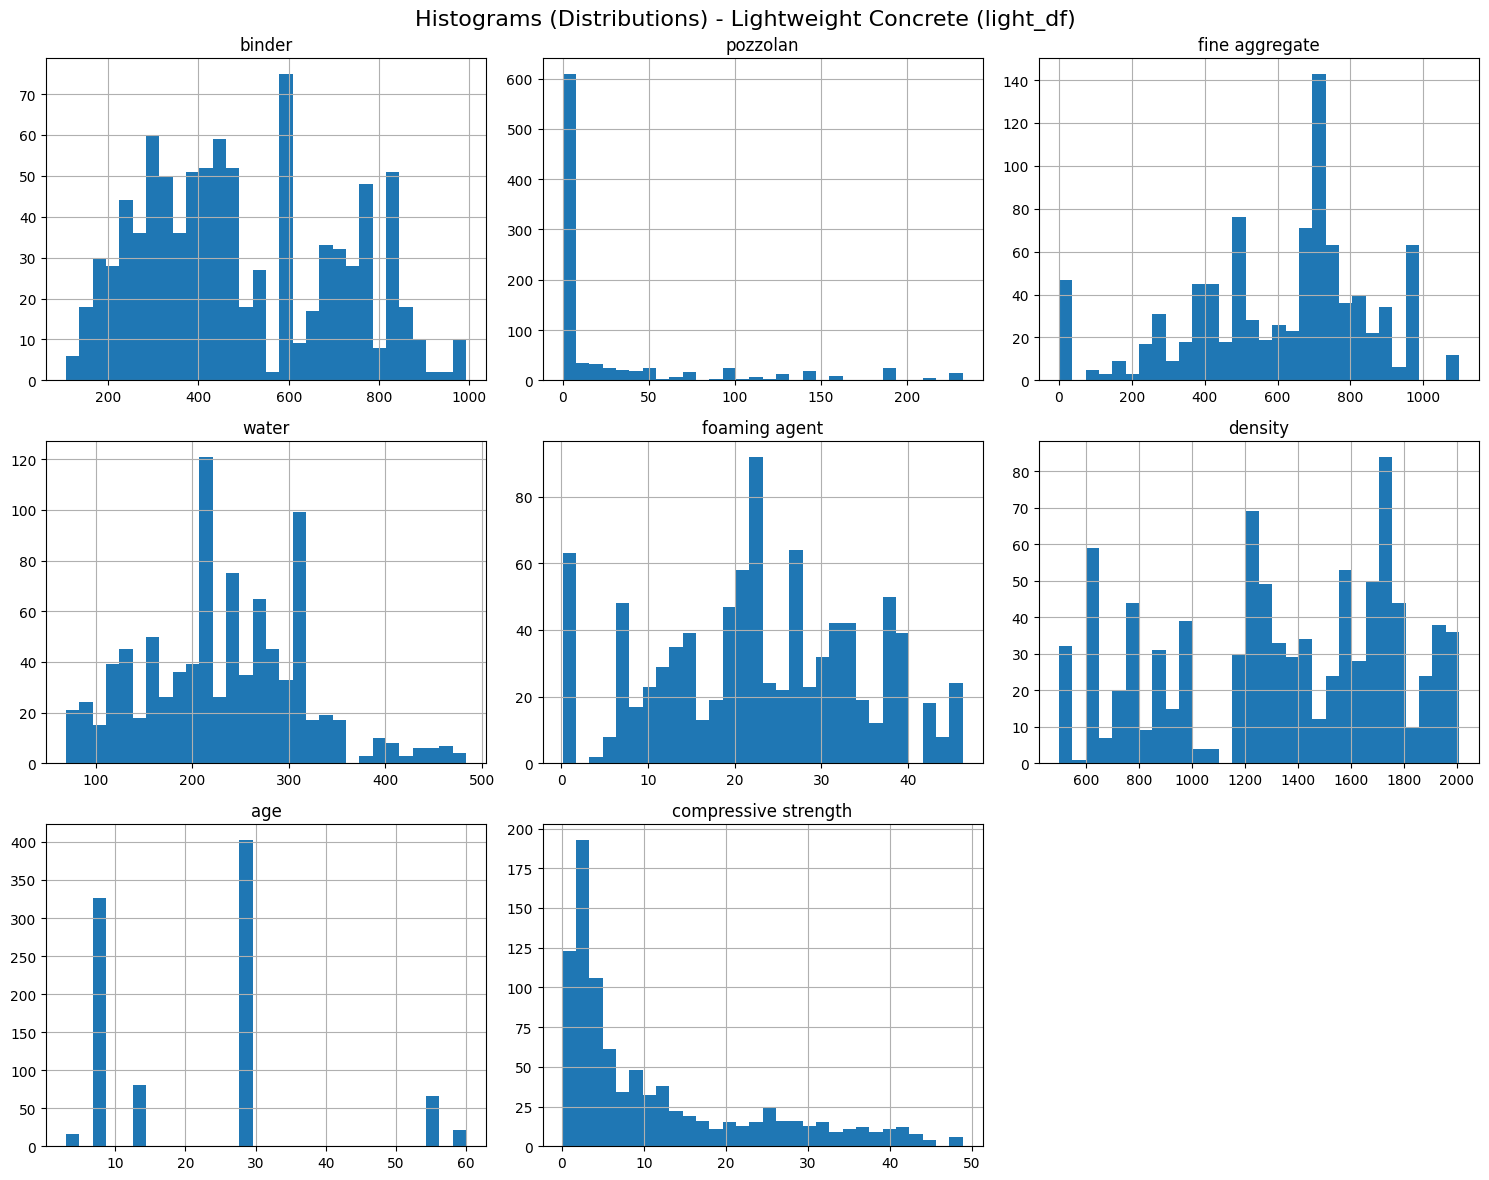

In [11]:
main_df = df.copy()
print(f"Lightweight original: {len(main_df)} rows")

main_df = main_df[main_df['age'] < 175]
main_df = main_df[main_df['pozzolan'] <= 250]
main_df = main_df[main_df['fine aggregate'] < 1100]
main_df = main_df[(main_df['density'] > 400) & (main_df['density'] <= 2200)]
main_df = main_df[main_df['binder'] > 0]
main_df = main_df[main_df['compressive strength'] > 0]
main_df = main_df[main_df['foaming agent'] < 50]

print(f"Lightweight after cleaning: {len(main_df)} rows\n")

analyze_dataset(main_df, "Lightweight Concrete (light_df)")

In [12]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 0 to 1005
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   binder                912 non-null    float64
 1   pozzolan              912 non-null    float64
 2   fine aggregate        912 non-null    float64
 3   water                 912 non-null    float64
 4   foaming agent         912 non-null    float64
 5   density               912 non-null    float64
 6   age                   912 non-null    int64  
 7   compressive strength  912 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 64.1 KB


In [13]:
main_df.describe().T

,count,mean,std,min,25%,50%,75%,max
binder,912.0,496.204539,211.795982,107.20,325.000,450.185,683.85000,992.80
pozzolan,912.0,26.982851,53.850722,0.00,0.000,0.000,25.00000,232.50
fine aggregate,912.0,602.281776,247.383851,0.00,426.600,675.000,758.20000,1098.00
water,912.0,233.005640,84.116711,68.90,169.000,234.000,290.52125,484.00
foaming agent,912.0,23.008070,11.908609,0.17,14.100,22.800,31.90000,46.30
density,912.0,1340.183399,433.512939,497.00,1000.000,1400.000,1724.14750,2009.48
age,912.0,21.589912,15.008985,3.00,7.000,28.000,28.00000,60.00
compressive strength,912.0,11.482921,12.080934,0.08,2.565,5.800,17.07000,48.88


In [14]:
main_df.nunique()

binder                  227
pozzolan                 86
fine aggregate          209
water                   206
foaming agent           181
density                 219
age                       6
compressive strength    697
dtype: int64

<Axes: >

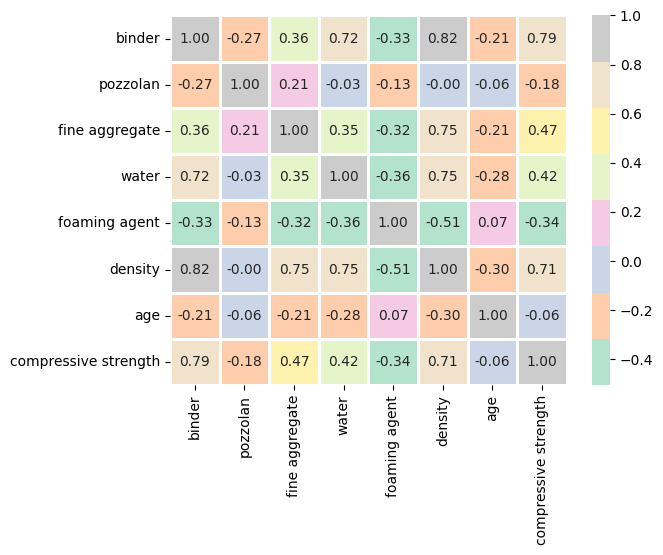

In [15]:
# Multivariate analysis

import seaborn as sns

sns.heatmap(main_df.corr(), annot=True, cmap='Pastel2', fmt='.2f', linewidths=2)

Dataset Preparation

In [16]:
X = main_df.drop('compressive strength', axis=1)
y = main_df['compressive strength']

X.shape, y.shape

((912, 7), (912,))

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((729, 7), (183, 7), (729,), (183,))

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR #support vector regression
from sklearn.neighbors import KNeighborsRegressor 
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE": mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

In [22]:
#Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

lr_evaluation = evaluate_model(y_test, pred_lr)

In [23]:
#Decision Tree Regressor

dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

dt_evaluation = evaluate_model(y_test, pred_dt)

In [24]:
#Random Forest

rf = RandomForestRegressor(n_estimators=200)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_evaluation = evaluate_model(y_test, pred_rf)

In [25]:
#Support Vector Regression

svm = SVR()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

svm_evaluation = evaluate_model(y_test, pred_svm)

In [26]:
#K-Nearest Neighbors

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

knn_evaluation = evaluate_model(y_test, pred_knn)

In [27]:
#XGBoost Regressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

xgb_evaluation = evaluate_model(y_test, pred_xgb)

In [28]:
# Artificial Neural Network

ann = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
)

ann.fit(X_train, y_train)

y_pred = ann.predict(X_test)

ann_evaluation = evaluate_model(y_test, y_pred)

In [29]:
results = pd.DataFrame([
    {
        'Model': 'Linear Regression',
        'R2 Score': lr_evaluation['R2 Score'],
        'MAE': lr_evaluation['MAE'],
        'MSE': lr_evaluation['MSE'],
        'RMSE': lr_evaluation['RMSE']
    },
    {
        'Model': 'Decision Tree',
        'R2 Score': dt_evaluation['R2 Score'],
        'MAE': dt_evaluation['MAE'],
        'MSE': dt_evaluation['MSE'],
        'RMSE': dt_evaluation['RMSE']
    },
    {
        'Model': 'Random Forest',
        'R2 Score': rf_evaluation['R2 Score'],
        'MAE': rf_evaluation['MAE'],
        'MSE': rf_evaluation['MSE'],
        'RMSE': rf_evaluation['RMSE']
    },
    {
        'Model': 'Support Vector Regression',
        'R2 Score': svm_evaluation['R2 Score'],
        'MAE': svm_evaluation['MAE'],
        'MSE': svm_evaluation['MSE'],
        'RMSE': svm_evaluation['RMSE']
    },
    {
        'Model': 'K-Nearest Neighbors',
        'R2 Score': knn_evaluation['R2 Score'],
        'MAE': knn_evaluation['MAE'],
        'MSE': knn_evaluation['MSE'],
        'RMSE': knn_evaluation['RMSE']
    },
    {
        'Model': 'XGBoost',
        'R2 Score': xgb_evaluation['R2 Score'],
        'MAE': xgb_evaluation['MAE'],
        'MSE': xgb_evaluation['MSE'],
        'RMSE': xgb_evaluation['RMSE']
    },
    {
        'Model': 'ANN',
        'R2 Score': ann_evaluation['R2 Score'],
        'MAE': ann_evaluation['MAE'],
        'MSE': ann_evaluation['MSE'],
        'RMSE': ann_evaluation['RMSE']
    }
])

results

,Model,R2 Score,MAE,MSE,RMSE
0,Linear Regression,0.733061,4.662340,37.479190,6.122025
1,Decision Tree,0.948367,1.217513,7.249420,2.692475
2,Random Forest,0.976929,0.964847,3.239284,1.799801
3,Support Vector Regression,0.853633,2.806827,20.550469,4.533262
4,K-Nearest Neighbors,0.928496,1.826450,10.039343,3.168492
5,XGBoost,0.975720,1.029386,3.408925,1.846327
6,ANN,0.938159,1.770227,8.682753,2.946651


Visualization

In [30]:
import matplotlib.pyplot as plt

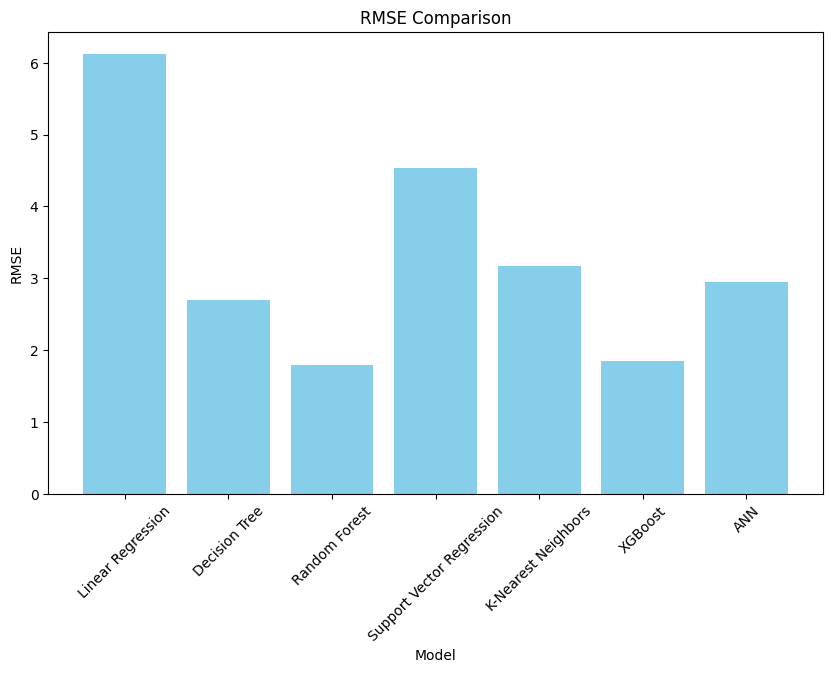

In [31]:
#RMSE Comparison:  lower, the better

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['RMSE'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.xticks(rotation=45)
plt.show()

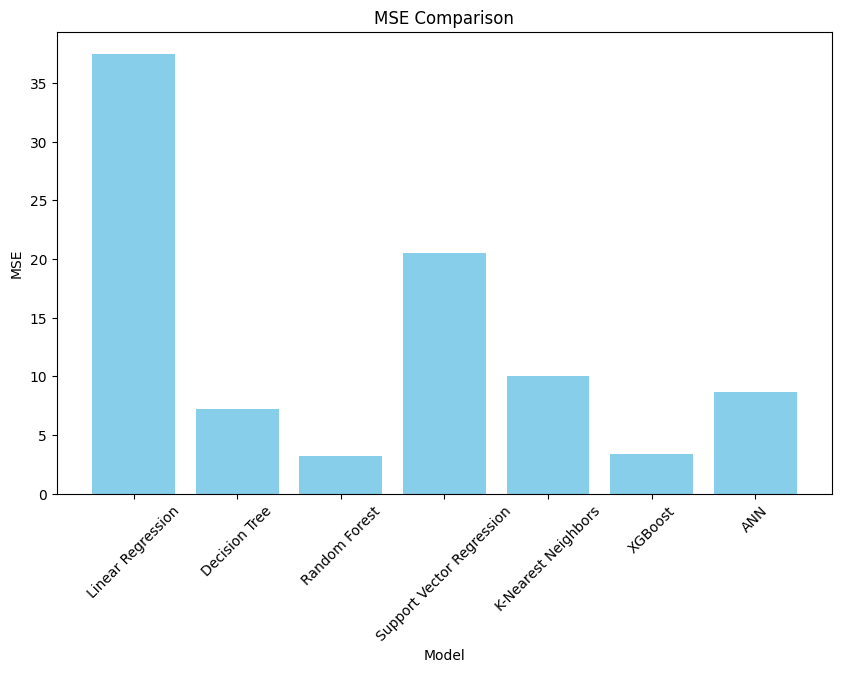

In [32]:
#MSE Comparison:  lower, the better

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['MSE'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.title('MSE Comparison')
plt.xticks(rotation=45)
plt.show()

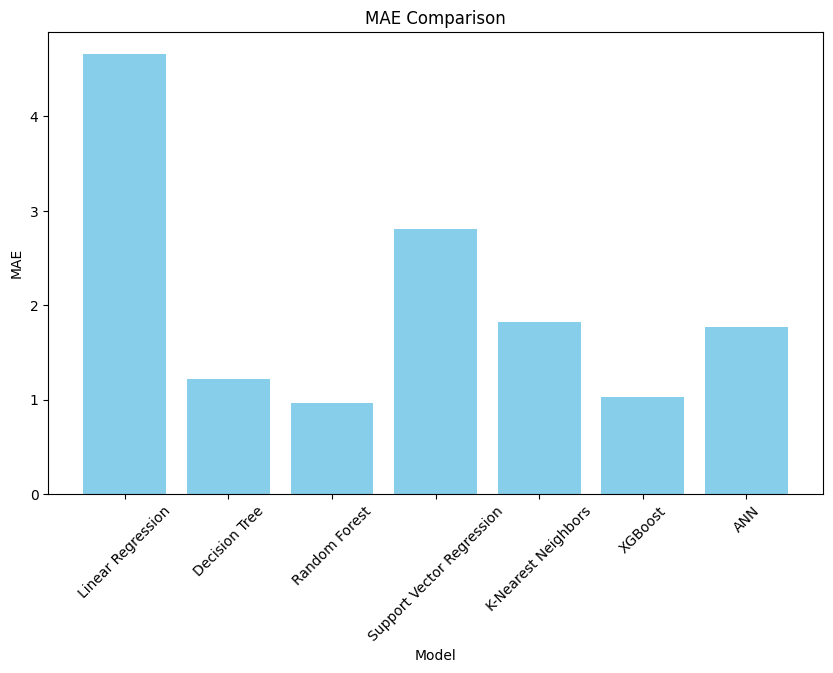

In [33]:
#MAE Comparison:  lower, the better

plt.figure(figsize=(10,6))
plt.bar(results['Model'], results['MAE'], color='skyblue')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('MAE Comparison')
plt.xticks(rotation=45)
plt.show()

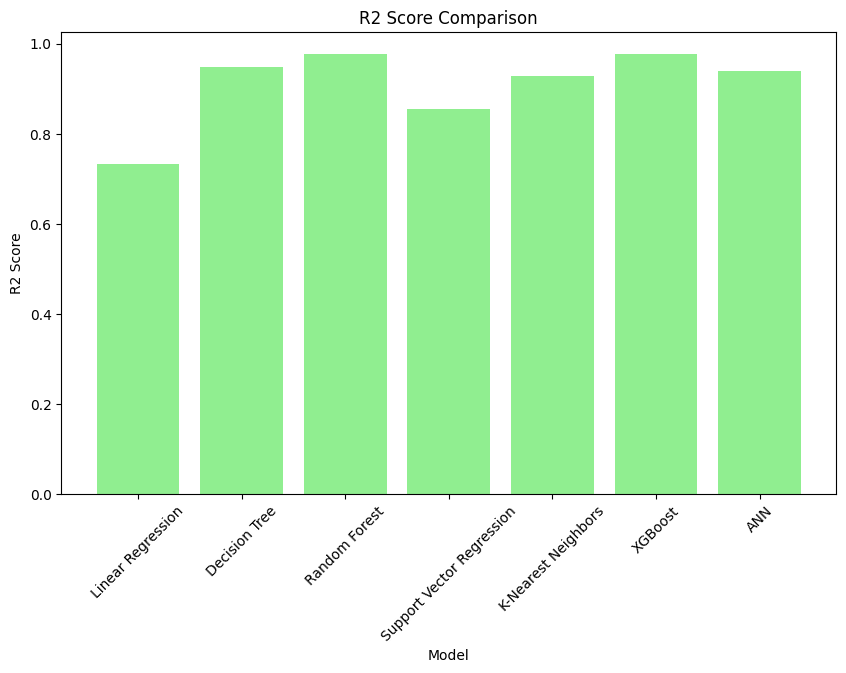

In [34]:
#R2 SCORE Comparison: higher, the better

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['R2 Score'], color='lightgreen')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison')
plt.xticks(rotation=45)
plt.show()

Linear Regression and Support Vector Regression (as usual, similar to geopolymer dataset analysis) not performing well, here after, these 2 models are ignored all together for the rest of the analysis.

Decision Tree Regressor and K-Nearest Neighbors are performing decently, with an R2 score of 0.82, and a MAE of 3.5 MPa. These 2 are able to model the data better than the linear regression and support vector regression. But not the best performing models.

Artificial Neural Network is performing decently, with an R2 score of 0.85, and a MAE of 3 MPa. This model is able to model the data better than the linear regression and support vector regression. But not the best performing models. It can be considered as a second best performing model after the 2 tree based models.

Random Forest Regressor and Gradient Boosting Regressor are performing the best, with an R2 score of 0.88, and a MAE of 2.5 MPa. These 2 models are able to model the data better than the other 3 models. These models are able to capture the non-linear relationships in the data better than the other models.

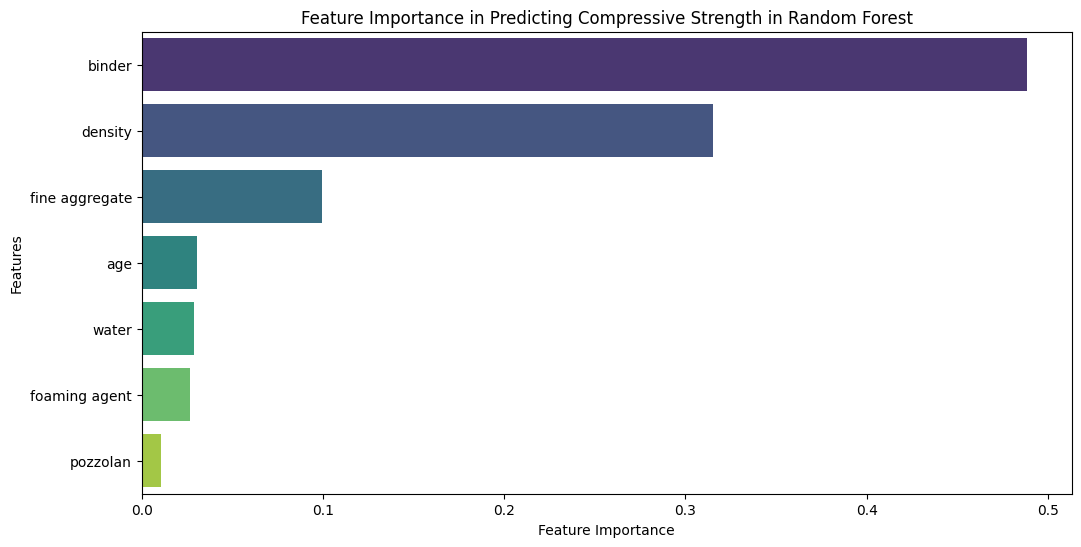


Feature Importances:
          feature  importance
0          binder    0.488628
5         density    0.315049
2  fine aggregate    0.099489
6             age    0.030465
3           water    0.028680
4   foaming agent    0.026829
1        pozzolan    0.010860


In [37]:
    #feature importance of the random forest regression model.

rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=rf_importance, palette='viridis', hue='feature', legend=False)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Predicting Compressive Strength in Random Forest')
plt.show()

print("\nFeature Importances:")
print(rf_importance)

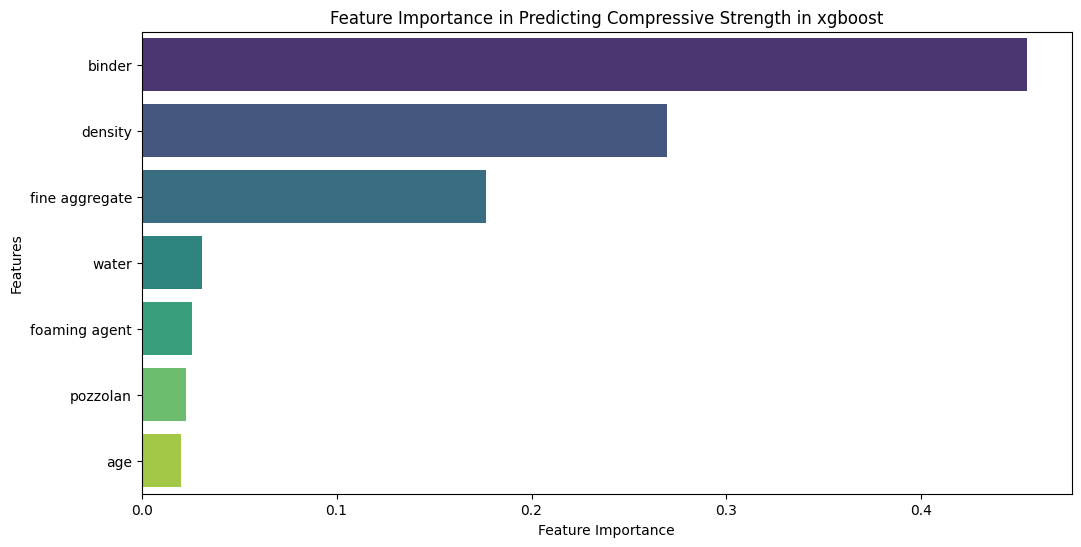


Feature Importances:
          feature  importance
0          binder    0.454348
5         density    0.269285
2  fine aggregate    0.176722
3           water    0.031168
4   foaming agent    0.025573
1        pozzolan    0.022687
6             age    0.020217


In [38]:
xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=xgb_importance, palette='viridis', hue='feature', legend=False)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Predicting Compressive Strength in xgboost')
plt.show()

print("\nFeature Importances:")
print(xgb_importance)

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
#gridsearchcv for XGBoost

xgb_params = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [5, 10, 15, None],
    "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.3],
    "subsample": [0.5, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 0.8, 0.9, 1.0],
}

xgb_model = XGBRegressor(random_state=42)

xgb_grid = GridSearchCV(estimator=xgb_model, param_grid=xgb_params, cv=5, scoring="neg_mean_squared_error", verbose=1, n_jobs=-1)
xgb_grid.fit(X_train, y_train)

best_xgb_gscv = xgb_grid.best_estimator_

print("Best Parameters:", xgb_grid.best_params_)
print("Best Score:", xgb_grid.best_score_)

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': None, 'n_estimators': 400, 'subsample': 0.5}
Best Score: -4.2501154469295495


In [41]:
best_xgb_gscv.predict(X_test)

xgb_gscv_evaluation = evaluate_model(y_test, best_xgb_gscv.predict(X_test))
print("\nEvaluation of the best XGBoost model found by GridSearchCV:")
print(f"R2 Score: {xgb_gscv_evaluation['R2 Score']:.4f}")
print(f"MAE: {xgb_gscv_evaluation['MAE']:.4f}")
print(f"MSE: {xgb_gscv_evaluation['MSE']:.4f}")
print(f"RMSE: {xgb_gscv_evaluation['RMSE']:.4f}")


Evaluation of the best XGBoost model found by GridSearchCV:
R2 Score: 0.9848
MAE: 0.9060
MSE: 2.1293
RMSE: 1.4592


In [42]:
#gridsearchcv for rf

rf_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [15, 20, 25, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(estimator=rf_model, param_grid=rf_params, cv=5, scoring="neg_mean_squared_error", verbose=1, n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Best Score: -7.9497856250208985


In [44]:
# optuna for Xgboost
import optuna
from sklearn.model_selection import cross_val_score, KFold
import logging

# Suppress Optuna logging
logging.getLogger('optuna').setLevel(logging.WARNING)

def xgb_objective(trial):
    params = {
        # Search space
        'n_estimators': trial.suggest_int('n_estimators', 300, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1 # Let XGBoost use all cores
    }

    model = XGBRegressor(**params)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    return np.mean(scores)

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=150, show_progress_bar=False)

best_xgb_params = xgb_study.best_params
print("Best XGBoost Parameters:", best_xgb_params)

Best XGBoost Parameters: {'n_estimators': 447, 'learning_rate': 0.03417125276555922, 'max_depth': 12, 'subsample': 0.5668995519476963}


In [45]:
# Training the best XGBoost model with the best parameters found by Optuna

best_xgb_optuna = XGBRegressor(**best_xgb_params)
best_xgb_optuna.fit(X_train, y_train)

y_pred_xgb_optuna = best_xgb_optuna.predict(X_test)

xgb_optuna_evaluation = evaluate_model(y_test, y_pred_xgb_optuna)

print("\nEvaluation of the best XGBoost model found by Optuna:")
print(f"R2 Score: {xgb_optuna_evaluation['R2 Score']:.4f}")
print(f"MAE: {xgb_optuna_evaluation['MAE']:.4f}")
print(f"MSE: {xgb_optuna_evaluation['MSE']:.4f}")
print(f"RMSE: {xgb_optuna_evaluation['RMSE']:.4f}")



Evaluation of the best XGBoost model found by Optuna:
R2 Score: 0.9824
MAE: 0.8596
MSE: 2.4669
RMSE: 1.5706


In [47]:
best_rf_pred = best_rf.predict(X_test)

best_xgb_pred = best_xgb_optuna.predict(X_test)

rf_best_eval = evaluate_model(y_test, best_rf_pred)
xgb_best_eval = evaluate_model(y_test, best_xgb_pred)

print("best rf model:\n", rf_best_eval)
print("best xgb model:\n", xgb_best_eval)

best rf model:
 {'RMSE': np.float64(1.801986361934837), 'MSE': 3.2471548485991493, 'MAE': 0.9594090271540638, 'R2 Score': 0.9768726787695955}
best xgb model:
 {'RMSE': np.float64(1.5706221926611268), 'MSE': 2.466854072079646, 'MAE': 0.8596198603983914, 'R2 Score': 0.9824302414841318}


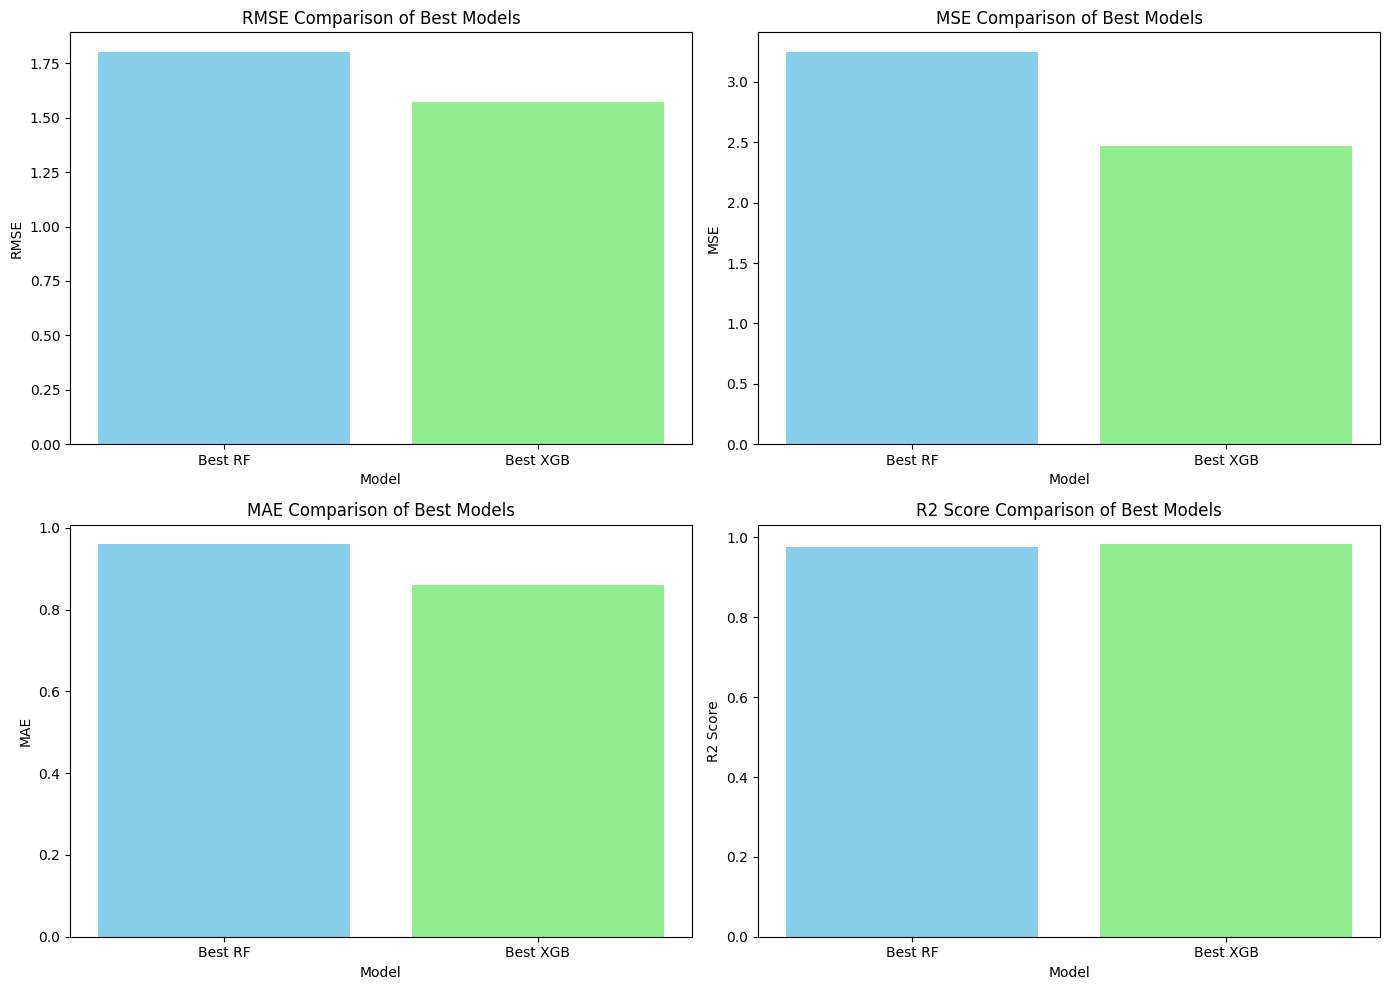

In [48]:
# Comparison of the best models - All metrics in one figure

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = ['Best RF', 'Best XGB']
colors = ['skyblue', 'lightgreen']

# RMSE comparison
axes[0, 0].bar(models, [rf_best_eval['RMSE'], xgb_best_eval['RMSE']], color=colors)
axes[0, 0].set_xlabel('Model')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('RMSE Comparison of Best Models')

# MSE comparison
axes[0, 1].bar(models, [rf_best_eval['MSE'], xgb_best_eval['MSE']], color=colors)
axes[0, 1].set_xlabel('Model')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].set_title('MSE Comparison of Best Models')

# MAE comparison
axes[1, 0].bar(models, [rf_best_eval['MAE'], xgb_best_eval['MAE']], color=colors)
axes[1, 0].set_xlabel('Model')
axes[1, 0].set_ylabel('MAE')
axes[1, 0].set_title('MAE Comparison of Best Models')

# R2 Score comparison
axes[1, 1].bar(models, [rf_best_eval['R2 Score'], xgb_best_eval['R2 Score']], color=colors)
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('R2 Score')
axes[1, 1].set_title('R2 Score Comparison of Best Models')

plt.tight_layout()
plt.show()

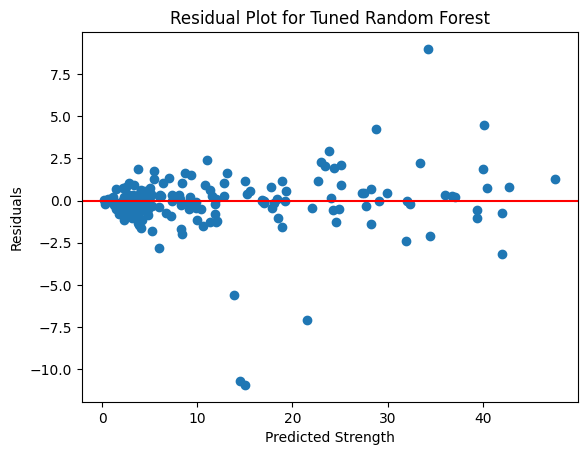

In [49]:
import matplotlib.pyplot as plt

residuals_rf = y_test - best_rf_pred

plt.scatter(best_rf_pred, residuals_rf)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")

plt.title("Residual Plot for Tuned Random Forest")

plt.show()

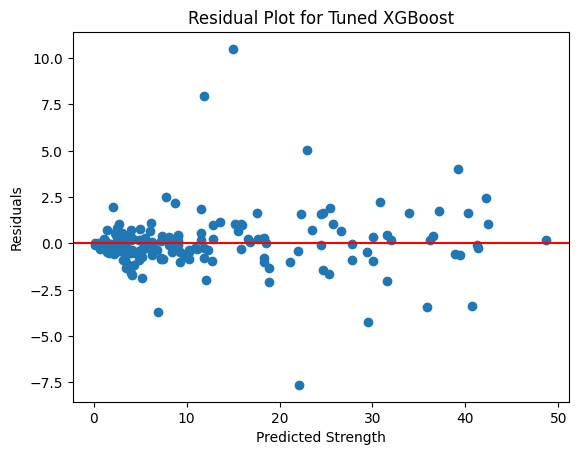

In [50]:
residuals_xgb = y_test - best_xgb_pred

plt.scatter(best_xgb_pred, residuals_xgb)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")

plt.title("Residual Plot for Tuned XGBoost")

plt.show()

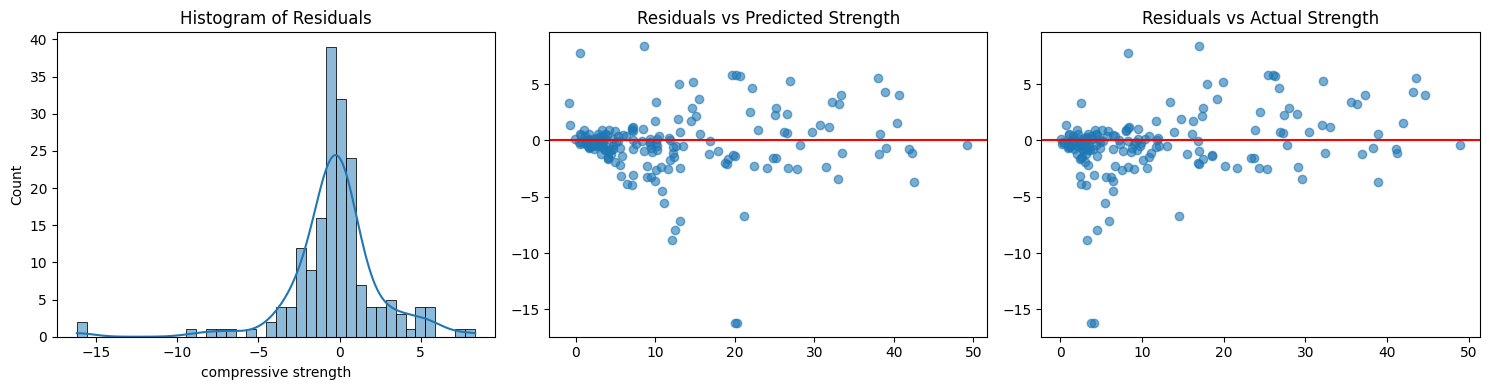

In [51]:
# After you have y_test and y_pred for a model
residuals = y_test - y_pred

plt.figure(figsize=(15, 4))

# 1. Residual histogram (check normality)
plt.subplot(1, 3, 1)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')

# 2. Residuals vs Predicted (you already have this)
plt.subplot(1, 3, 2)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.title('Residuals vs Predicted Strength')

# 3. Residuals vs Actual (very useful)
plt.subplot(1, 3, 3)
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='red')
plt.title('Residuals vs Actual Strength')

plt.tight_layout()
plt.show()